## Imports

In [1]:
import pickle
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lemminflect import getAllLemmas, getAllLemmasOOV
from nltk import pos_tag, word_tokenize
from num2words import num2words as _num2words
from scipy.interpolate import make_interp_spline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant, show_content_warning
from analysis_helpers.constants import (
    CV_PARAMS,
    ENDFRAME_TIMES,
    EPISODE_WINDOW_SIZE,
    LDA_PARAMS,
    LEMMATIZER_EXCLUSIONS,
    POS_MAPPING,
    PROCESSED_DIR,
    RECALL_WINDOW_SIZE,
    STOP_WORDS,
    TEXT_SUBSTITUTIONS
)

In [2]:
show_content_warning()

⚠️ The episodes of [*Atlanta*](https://en.wikipedia.org/wiki/Atlanta_(TV_series)) viewed by participants in this study explore themes of racism, homophobia, and other forms of discrimination. As a result, certain files in this repository&mdash;possibly including this one&mdash;contain references to language that may be offensive or harmful. This language appears only in service of accurately representing and analyzing the stimuli and participants' responses, and its inclusion does not reflect an endorsement of its use by the authors.

## Functions

In [3]:
def num2words(number: str) -> str:
    # loose heuristic for identifying years
    if len(number) == 4 and 1900 < int(number) < 2025:
        return _num2words(number, to='year')
    return _num2words(number, to='cardinal')

In [4]:
def lemmatize(word: str, treebank_tag: str) -> str:
    if (
            treebank_tag in LEMMATIZER_EXCLUSIONS['treebank_tags']
            or word.lower() in LEMMATIZER_EXCLUSIONS['words']
            or '_' in word    # n-grams from TEXT_SUBSTITUTIONS
            or '~' in word    # censored expletives
    ):
        return word
    
    universal_tag = POS_MAPPING.get(treebank_tag)
    # returns a dict of {POS: (lemmas, ...), ...}
    lemma_candidates = getAllLemmas(word, universal_tag)

    if len(lemma_candidates) == 0:
        # no lemmas found via dictionary lookup.
        # Word may not be lemmatizeable, or may have been mis-tagged
        # because sentence fragments in annotations & 
        # stream-of-consciousness in recall transcripts both confuse the 
        # POS tagger. Try re-tagging first.
        new_treebank_tag = pos_tag([word])[0][1]
        if new_treebank_tag != treebank_tag:
            return lemmatize(word, new_treebank_tag)
        
        # If we have a POS tag, also try rule-based lemmatization
        if universal_tag is not None:
            # returns a 1-item dict of {POS: (lemma,)}, or an empty dict
            lemma_candidates_oov = getAllLemmasOOV(word, universal_tag)
            if len(lemma_candidates_oov) == 0:
                return word
            
            lemma_oov = lemma_candidates_oov[universal_tag][0]
            if lemma_oov != word:
                if lemma_oov.endswith('z') and word[word.rindex('z') + 1] == 'e':
                    # when inflections of -ze verbs (e.g., "recognized", 
                    # "realizes", etc.) are mis-tagged as different POS, 
                    # rule-based lemmatizer removes trailing "e"
                    lemma_oov = f'{lemma_oov}e'

            return lemma_oov
        return word
    
    if len(lemma_candidates) > 1:
        # universal_tag is None and word has lemmas for multiple POS
        if any(len(pos_lemmas) > 1 for pos_lemmas in lemma_candidates.values()):
            # word has >1 possible lemma for at least 1 POS
            raise RuntimeError(
                f'Multiple potential lemmas found for "{word}" ({treebank_tag}'
                f' -> {universal_tag}):\n\t{lemma_candidates=}'
            )
        
        unique_lemmas = tuple(set(
            pos_lemmas[0] for pos_lemmas in lemma_candidates.values()
        ))
        if len(unique_lemmas) > 1:
            # word has different possible lemmas for different POS.
            # Default to choosing the shortest one.
            if any(len(lem) == len(unique_lemmas[0]) for lem in unique_lemmas[1:]):
                # no single shortest option to choose
                raise RuntimeError(
                    f'Multiple potential lemmas found for "{word}" '
                    f'({treebank_tag} -> {universal_tag}):\n\t{lemma_candidates=}'
                )
            return min(unique_lemmas, key=len)
        return unique_lemmas[0]
    
    # Note: checked all instances in episode annotations where >1 lemma 
    # found for given word/POS, and 1st option is always the "right" one
    return tuple(lemma_candidates.values())[0][0]

In [5]:
def preprocess_text(text: str) -> str:
    # combine n-grams, standardize names, replace euphemisms, etc. 
    # before tokenizing/lemmatizing
    for pattern, replacement in TEXT_SUBSTITUTIONS.items():
        text = pattern.sub(replacement, text)
    
    # convert digits to word form
    text = re.sub(r'(\d+)', lambda match: num2words(match.group(0)), text)
    
    # temporarily replace asterisks in censored expletives with tildes 
    # so the tokenizer doesn't split on them
    text = text.replace('*', '~')
    
    # tokenize, POS tag, lemmatize
    lemmas = []
    for token, tag in pos_tag(word_tokenize(text)):
        if token.lower() not in STOP_WORDS:
            lemmas.append(lemmatize(token, tag))
    
    text = ' '.join(lemmas).replace('~', '*')
    
    # normalize case, remove all punctuation except _ and *
    text = re.sub(r"[.,!?:;/'`()[\]-]+", ' ', text).lower()
    
    # normalize whitespace, remove any additional stop-words introduced 
    # by lemmatization/punctuation removal
    return ' '.join(token for token in text.split() if token not in STOP_WORDS)

In [6]:
def parse_windows(textlist, wsize):
    windows = []
    for ix in range(wsize // 2, wsize):
        windows.append(' '.join(textlist[0 : ix]))
    for ix in range(len(textlist) - wsize // 2 + 1):
        windows.append(' '.join(textlist[ix : ix + wsize]))
    return windows

In [7]:
def get_midpoint_times(onsets, wsize, endframe_time):
    midpoint_times = []
    for ix in range(wsize // 2, wsize):
        midpoint_times.append(onsets[ix] / 2)
    for ix in range(len(onsets) - wsize // 2 + 1):
        try:
            midpoint_times.append((onsets[ix] + onsets[ix + wsize]) / 2)
        except IndexError:
            midpoint_times.append((onsets[ix] + endframe_time) / 2)
    return midpoint_times

In [8]:
def scale_recall_timeseries(
        rec_windows: list[str], 
        wsize: float, 
        episode_tmax: float
) -> np.ndarray:
    tvals = [0]
    next_tval = 0
    for window in rec_windows[1:]:
        delta_t = len(window.split()) / wsize
        next_tval += delta_t
        tvals.append(next_tval)
    
    return np.array(tvals) * int(episode_tmax) / tvals[-1]

In [9]:
def resample_trajectory(
        trajectory: np.ndarray, 
        timestamps: list[float], 
        new_tmax: float, 
        resolution: int = 1
) -> np.ndarray[float]:
    new_timepoints = np.arange(int(new_tmax) + resolution, step=resolution)
    spline = make_interp_spline(timestamps, trajectory, k=1, axis=0)
    return spline(new_timepoints, extrapolate=True)

In [10]:
def get_top_words(cv, lda, n_words=10, active_only=False, return_weights=False):
    topic_words = {}
    vocab = cv.get_feature_names_out()
    topic_words_distribution = lda.components_ / lda.components_.sum(axis=1)[:, None]
    
    if active_only:
#         topic_ixs = np.nonzero(np.ptp(topic_words_distribution, axis=1))[0]
        topic_ixs = np.nonzero(lda.components_.var(axis=1) > 1e-6)[0].tolist()
    else:
        topic_ixs = range(len(lda.components_))
        
    if n_words == -1:
        # n_words=-1 means all words with any (non-baseline) weight in that topic
        get_top_ixs = lambda w: w.argsort()[::-1][:sum(w != w.min())]
    else:
        # otherwise return the top-weighted n_words words
        get_top_ixs = lambda w: w.argsort()[::-1][:n_words]
    
    if return_weights:
        # return_weights=True: dict values are lists of (word, weight) tuples
        get_words_weights = lambda w, ixs: list(zip((vocab[ixs], w[ixs].tolist())))
    else:
        # otherwise dict values are lists of words
        get_words_weights = lambda w, ixs: vocab[ixs].tolist()
        
    for topic_ix in topic_ixs:
        word_weights = topic_words_distribution[topic_ix]
        top_ixs = get_top_ixs(word_weights)
        topic_words[topic_ix] = get_words_weights(word_weights, top_ixs)
        
    return topic_words

## Load data

In [11]:
atlep1 = Episode('atlep1')
# atlep2 = Episode('atlep2')
# arrdev = Episode('arrdev')

participants = Participant.load_all()
avg_participant = Participant('average')

## Transform episodes

In [12]:
# for episode in (atlep1, atlep2, arrdev):
for episode in (atlep1,):
    processed_annotations = (
        episode.annotations
        # drop frame, onset time, & (manually labeled) scene name cols
        .loc[:, 'Narrative details (external events)':'Setting']
#         .loc[:, include_cols]
        # concatenate all annotated features for each shot. Adding 
        # period as delimiter helps POS tagger
        .apply(lambda row: '. '.join(row.dropna()), axis=1)
        # remove period delimiter if annotation text already ended with 
        # punctuation
        .str.replace(r'(?<=\W)\. ', ' ', regex=True)
        # remove single quotes (used for nested quotes in "Speech" 
        # column). Leave apostrophes used in plural possessives (Xs') & 
        # shortened gerunds (Xin') to be handled separately.
        .str.replace(r"(?<=\W)'|(?<!s)(?<!in)'(?=\W)", '', regex=True)
        # run preprocessing
        .apply(preprocess_text)
        .tolist()
    )
    
    # parse annotations into overlapping sliding windows
    episode.windows = parse_windows(processed_annotations, wsize=EPISODE_WINDOW_SIZE)
    
    # vectorize windows to token counts
    episode.fit_cv = CountVectorizer(**CV_PARAMS).fit(episode.windows)
    window_wordcounts = episode.fit_cv.transform(episode.windows)
    
    # fit topic model to sliding windows and transform
    episode.fit_lda = LatentDirichletAllocation(**LDA_PARAMS).fit(window_wordcounts)
    window_trajectory = episode.fit_lda.transform(window_wordcounts)
    
    # resample trajectory to 1 sample per second of video
    midpoint_times = get_midpoint_times(episode.annotations['Onset time'].tolist(), 
                                        wsize=EPISODE_WINDOW_SIZE, 
                                        endframe_time=episode.endframe_time)
    episode.trajectory = resample_trajectory(window_trajectory, 
                                             timestamps=midpoint_times, 
                                             new_tmax=episode.endframe_time)

In [13]:
topics_top_words = get_top_words(atlep1.fit_cv, atlep1.fit_lda, n_words=10, active_only=True)
print(f'\033[1m{len(topics_top_words)} active topics\033[0m:\n{"="*17}')
for topic, words in topics_top_words.items():
    print(f'\033[1mTopic {topic+1}:\033[0m\n    {", ".join(words)}')

23 active topics:
Topic 6:
    earn, parent, father, house, outdoor, mother, ask, alfred_paper_boy, use, strained
Topic 8:
    van, reporter, earn, apartment, indoor, mother, tv, news, walk, suspect
Topic 11:
    alfred_paper_boy, earn, outdoor, store, convenience, parking_lot, darius, song, bus, car
Topic 14:
    earn, bus, outdoor, lottie, man, look, stranger, turn, strange, phone
Topic 19:
    dave, earn, radio_station, parking_lot, outdoor, say, kp, play, song, ask
Topic 20:
    alfred_paper_boy, outdoor, darius, earn, couch, start, cut, phone, man, sex
Topic 23:
    alfred_paper_boy, earn, man, outdoor, convenience, parking_lot, store, hey, woman, van
Topic 24:
    earn, dave, prince, radio_station, outdoor, parking_lot, janitor, walk, n***a, use
Topic 25:
    earn, darius, outdoor, alfred_paper_boy, couch, marijuana, know, say, take, ask
Topic 26:
    earn, alfred_paper_boy, father, radio_station, dave, outdoor, look, indoor, say, money
Topic 27:
    earn, dave, alfred_paper_boy,

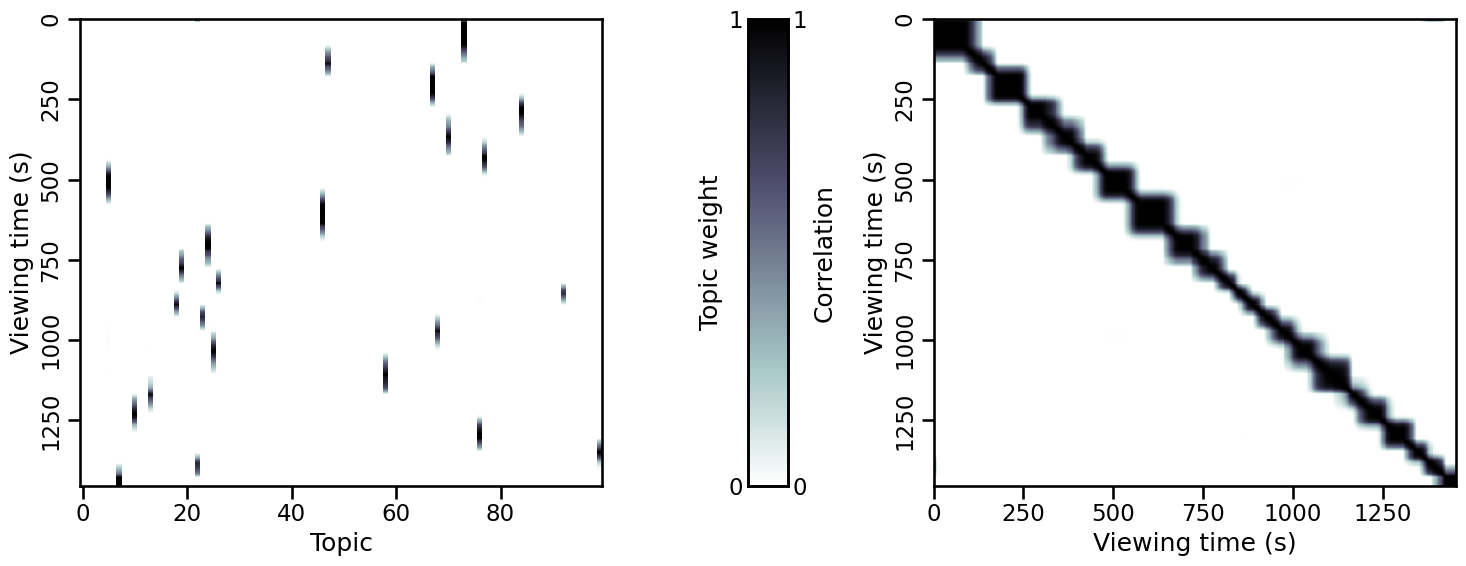

In [14]:
HEATMAP_CMAP = 'bone_r'
HEATMAP_VMIN = 0
HEATMAP_VMAX = 1

for episode in (atlep1,):
    with sns.plotting_context('talk'):
        fig, (ax1, cbar_ax, ax2) = plt.subplots(
            1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': (1, 0.075, 1)}
        )
        sns.heatmap(episode.trajectory,
                    vmin=HEATMAP_VMIN,
                    vmax=HEATMAP_VMAX,
                    cmap=HEATMAP_CMAP,
                    cbar=False,
                    xticklabels=20,
                    yticklabels=250,
                    ax=ax1)
        for spine in ax1.spines.values():
            spine.set_visible(True)
        ax1.set_xlabel('Topic')
        ax1.set_ylabel('Viewing time (s)')

        sns.heatmap(np.corrcoef(episode.trajectory),
                    vmin=HEATMAP_VMIN,
                    vmax=HEATMAP_VMAX,
                    cmap=HEATMAP_CMAP,
                    cbar=False,
                    xticklabels=250,
                    yticklabels=250,
                    ax=ax2)
        for spine in ax2.spines.values():
            spine.set_visible(True)
        ax2.set_xlabel('Viewing time (s)')
        ax2.set_ylabel('Viewing time (s)')

        cbar_norm = mpl.colors.Normalize(HEATMAP_VMIN, HEATMAP_VMAX)
        cbar_mappable = mpl.cm.ScalarMappable(norm=cbar_norm, cmap=HEATMAP_CMAP)
        plt.colorbar(cbar_mappable, cax=cbar_ax, label='Topic weight')
        cbar_ax.set_yticks([0, 1])
        cbar_ax.yaxis.set_label_position('left')
        cbar_ax.tick_params(left=False, length=0)
        twin_cbar_ax = cbar_ax.twinx()
        twin_cbar_ax.set_ylim(HEATMAP_VMIN, HEATMAP_VMAX)
        twin_cbar_ax.set_ylabel('Correlation')
        twin_cbar_ax.set_yticks([0, 1])
        twin_cbar_ax.tick_params(right=False, length=0)

        plt.tight_layout()
        plt.show()

## Transform recalls

In [15]:
# pbar = tqdm(total=len(participants) * 3, leave=False)
# for rectype, episode in zip(('atlep1', 'delayed', 'atlep2', 'arrdev'), 
#                             (atlep1, atlep1, atlep2, arrdev)):

pbar = tqdm(total=len(participants) * 2, leave=False)
for rectype, episode in zip(('atlep1', 'delayed'), (atlep1, atlep1)):
    rectype_trajs = []
    for p in participants:
        pbar.set_description(f'{rectype}, P{p.sub_n}')
#         if (
#                 (rectype == 'atlep2' and p.condition == 'B') 
#                 or (rectype == 'arrdev' and p.condition == 'A')
#         ):
#             continue
        
        processed_transcript = preprocess_text(p.transcripts[rectype])
        p.windows[rectype] = parse_windows(processed_transcript.split(), 
                                           wsize=RECALL_WINDOW_SIZE)
        
        window_wordcounts = episode.fit_cv.transform(p.windows[rectype])
        window_trajectory = episode.fit_lda.transform(window_wordcounts)
        
        window_tpts = scale_recall_timeseries(p.windows[rectype], 
                                              wsize=RECALL_WINDOW_SIZE, 
                                              episode_tmax=episode.endframe_time)
        p.trajectories[rectype] = resample_trajectory(window_trajectory, 
                                                      timestamps=window_tpts, 
                                                      new_tmax=episode.endframe_time)
        rectype_trajs.append(p.trajectories[rectype])
        pbar.update()
        
    avg_participant.trajectories[rectype] = np.mean(rectype_trajs, axis=0)
        
pbar.close()

  0%|          | 0/114 [00:00<?, ?it/s]

## Save data

In [16]:
for episode in (atlep1,):
    np.save(episode.data_dir.joinpath('windows.npy'), episode.windows)
    np.save(episode.data_dir.joinpath('trajectory.npy'), episode.trajectory)
    episode.data_dir.joinpath('fit_cv.p').write_bytes(pickle.dumps(episode.fit_cv))
    episode.data_dir.joinpath('fit_lda.p').write_bytes(pickle.dumps(episode.fit_lda))
    
for p in participants:
    p.data_dir.mkdir(exist_ok=True)
    for rectype in ('atlep1', 'delayed'):
        np.save(p.data_dir.joinpath(f'{rectype}_recall_windows.npy'), 
                p.windows[rectype])
        np.save(p.data_dir.joinpath(f'{rectype}_recall_trajectory.npy'), 
                p.trajectories[rectype])
        
avg_participant.data_dir.mkdir(exist_ok=True)
for rectype in ('atlep1', 'delayed'):
    np.save(avg_participant.data_dir.joinpath(f'{rectype}_recall_trajectory.npy'), 
            avg_participant.trajectories[rectype])